In [2]:
# Cell 1 — Load the data
import json
import pandas as pd

records = []
with open("/content/drive/MyDrive/News_Category_Dataset_v3.json", "r") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)
print(df.shape)

(209527, 6)


In [3]:
# Cell 2 — Peek at the data
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [4]:
# Cell 3 — Column types, non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209527 entries, 0 to 209526
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   link               209527 non-null  object
 1   headline           209527 non-null  object
 2   category           209527 non-null  object
 3   short_description  209527 non-null  object
 4   authors            209527 non-null  object
 5   date               209527 non-null  object
dtypes: object(6)
memory usage: 9.6+ MB


In [5]:
# Cell 4 — Check for NaN/None missing values
df.isnull().sum()

,0
link,0
headline,0
category,0
short_description,0
authors,0
date,0


In [6]:
# Cell 5 — Check for empty strings (isnull() misses these)
print((df['authors'] == '').sum())
print((df['short_description'] == '').sum())

37418
19712


In [7]:
# Cell 6 — Fix blank authors
df['authors'] = df['authors'].replace('', 'Unknown')

In [8]:
# Cell 7 — Look at category column
print(df['category'].nunique())
print(df['category'].value_counts())

42
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUC

In [9]:
sample = df.short_description
df = df[sample != '']
print(df.shape)

(189815, 6)


In [10]:
df.duplicated().sum()
df = df[df.duplicated() == False]
print(df.shape)

(189802, 6)


In [11]:
df["text"] = df["headline"] + " " + df["short_description"]
df.text.head()

,text
0,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...


In [12]:
df[['headline', 'short_description', 'text']].head()

,headline,short_description,text
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,Over 4 Million Americans Roll Up Sleeves For O...
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,"American Airlines Flyer Charged, Banned For Li..."
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",23 Of The Funniest Tweets About Cats And Dogs ...
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",The Funniest Tweets From Parents This Week (Se...
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Woman Who Called Cops On Black Bird-Watcher Lo...


In [13]:
print(df['date'].min())
print(df['date'].max())

2012-01-28
2022-09-23


In [14]:
df['text_length'] = df['text'].str.len()
df['text_length'].describe()

,text_length
count,189802.000000
mean,185.791198
std,72.158103
min,18.000000
25%,139.000000
50%,177.000000
75%,214.000000
max,1487.000000


In [15]:
df = df[df['text_length'] >= 27]
print(df.shape)

(189796, 8)


In [16]:
df['category'].nunique()
df['category'].value_counts()

,count
category,
POLITICS,32436
WELLNESS,17940
ENTERTAINMENT,14774
STYLE & BEAUTY,9799
TRAVEL,9421
PARENTING,8790
FOOD & DRINK,6331
QUEER VOICES,5603
HEALTHY LIVING,5265


In [17]:
df['category'] = df['category'].replace({
    'WORLDPOST': 'THE WORLDPOST',
    'ARTS': 'ARTS & CULTURE',
    'CULTURE & ARTS': 'ARTS & CULTURE',
    'STYLE': 'STYLE & BEAUTY',
    'PARENTS': 'PARENTING',
    'HEALTHY LIVING': 'WELLNESS',
    'GREEN': 'ENVIRONMENT',
    'TASTE': 'FOOD & DRINK',
    'COLLEGE': 'EDUCATION'
})

In [18]:
df['category'].nunique()
df['category'].value_counts()

,count
category,
POLITICS,32436
WELLNESS,23205
ENTERTAINMENT,14774
PARENTING,12346
STYLE & BEAUTY,11366
TRAVEL,9421
FOOD & DRINK,8271
QUEER VOICES,5603
BUSINESS,5132


In [19]:
df_sample = df.sample(n= 30000, random_state= 42)
print(df_sample.shape)
print(df_sample['category'].value_counts())

(30000, 8)
category
POLITICS          5075
WELLNESS          3728
ENTERTAINMENT     2350
PARENTING         1917
STYLE & BEAUTY    1761
TRAVEL            1487
FOOD & DRINK      1326
QUEER VOICES       905
THE WORLDPOST      761
BUSINESS           757
SPORTS             733
COMEDY             729
BLACK VOICES       694
HOME & LIVING      694
WEDDINGS           621
ENVIRONMENT        556
ARTS & CULTURE     541
DIVORCE            531
WORLD NEWS         525
WOMEN              491
IMPACT             472
CRIME              435
WEIRD NEWS         366
MEDIA              365
TECH               317
RELIGION           315
MONEY              284
EDUCATION          284
SCIENCE            260
U.S. NEWS          210
GOOD NEWS          178
FIFTY              174
LATINO VOICES      158
Name: count, dtype: int64


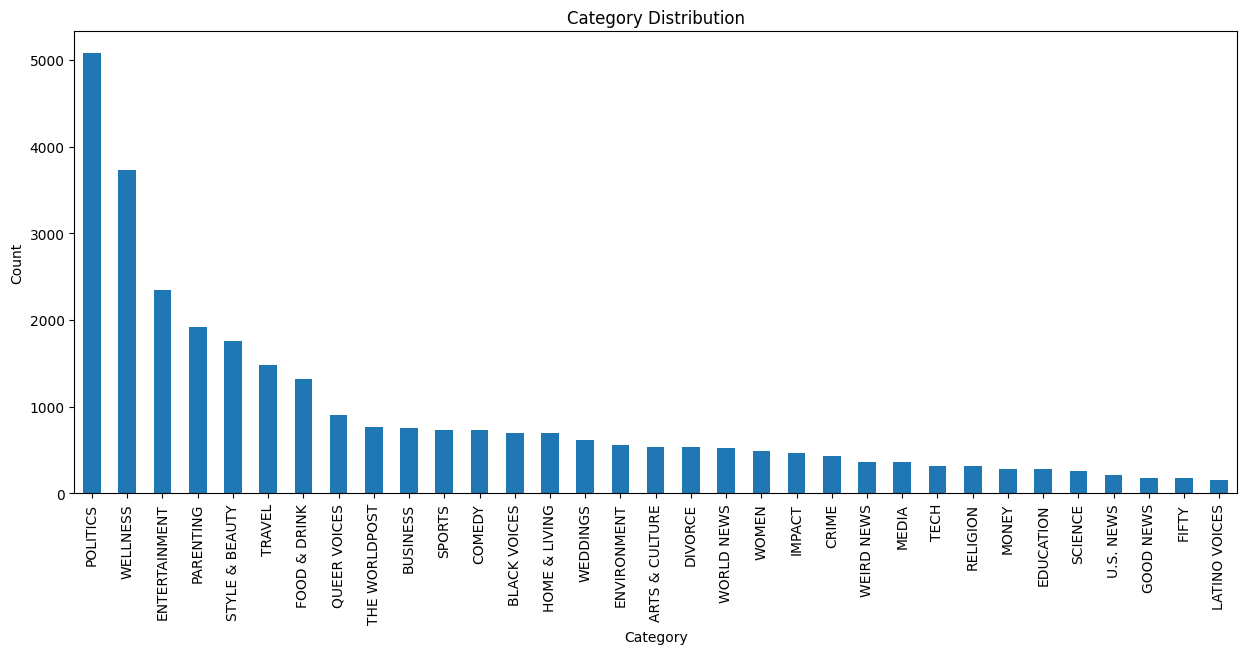

In [20]:
import matplotlib.pyplot as plt

df_sample['category'].value_counts().plot(kind = 'bar', figsize = (15,6))
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

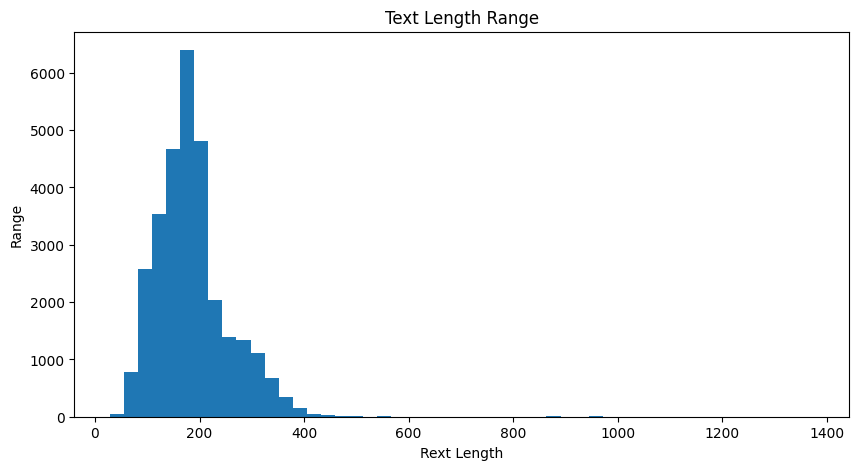

In [25]:
df_sample['text_length'].plot(kind = 'hist', bins = 50, figsize = (10,5))
plt.title('Text Length Range')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

In [46]:
df_sample['date'] = pd.to_datetime(df['date'])

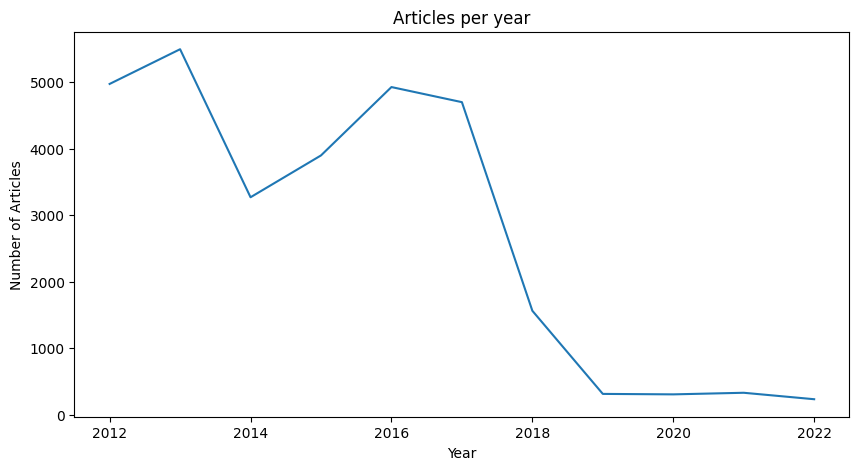

In [47]:
df_sample['date'].dt.year.value_counts().sort_index().plot(kind = 'line', figsize = (10, 5))
plt.title('Articles per year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.show()

In [48]:
df_sample.to_csv("news_cleaned.csv", index=False)